In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')




In [31]:
df = pd.read_csv('Walmart_Sales.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values('Date').reset_index(drop=True)
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

In [32]:
print(f"Total Records: {len(df):,}")
print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total Stores: {df['Store'].nunique()}")
print(f"Total Weeks: {df['Date'].nunique()}")
print(f"\nWeekly Sales Summary:")
print(df['Weekly_Sales'].describe())
print(f"\nHoliday Weeks: {df[df['Holiday_Flag']==1]['Date'].nunique()}")
print(f"Non-Holiday Weeks: {df[df['Holiday_Flag']==0]['Date'].nunique()}")

Total Records: 6,435
Date Range: 2010-02-05 to 2012-10-26
Total Stores: 45
Total Weeks: 143

Weekly Sales Summary:
count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64

Holiday Weeks: 10
Non-Holiday Weeks: 133


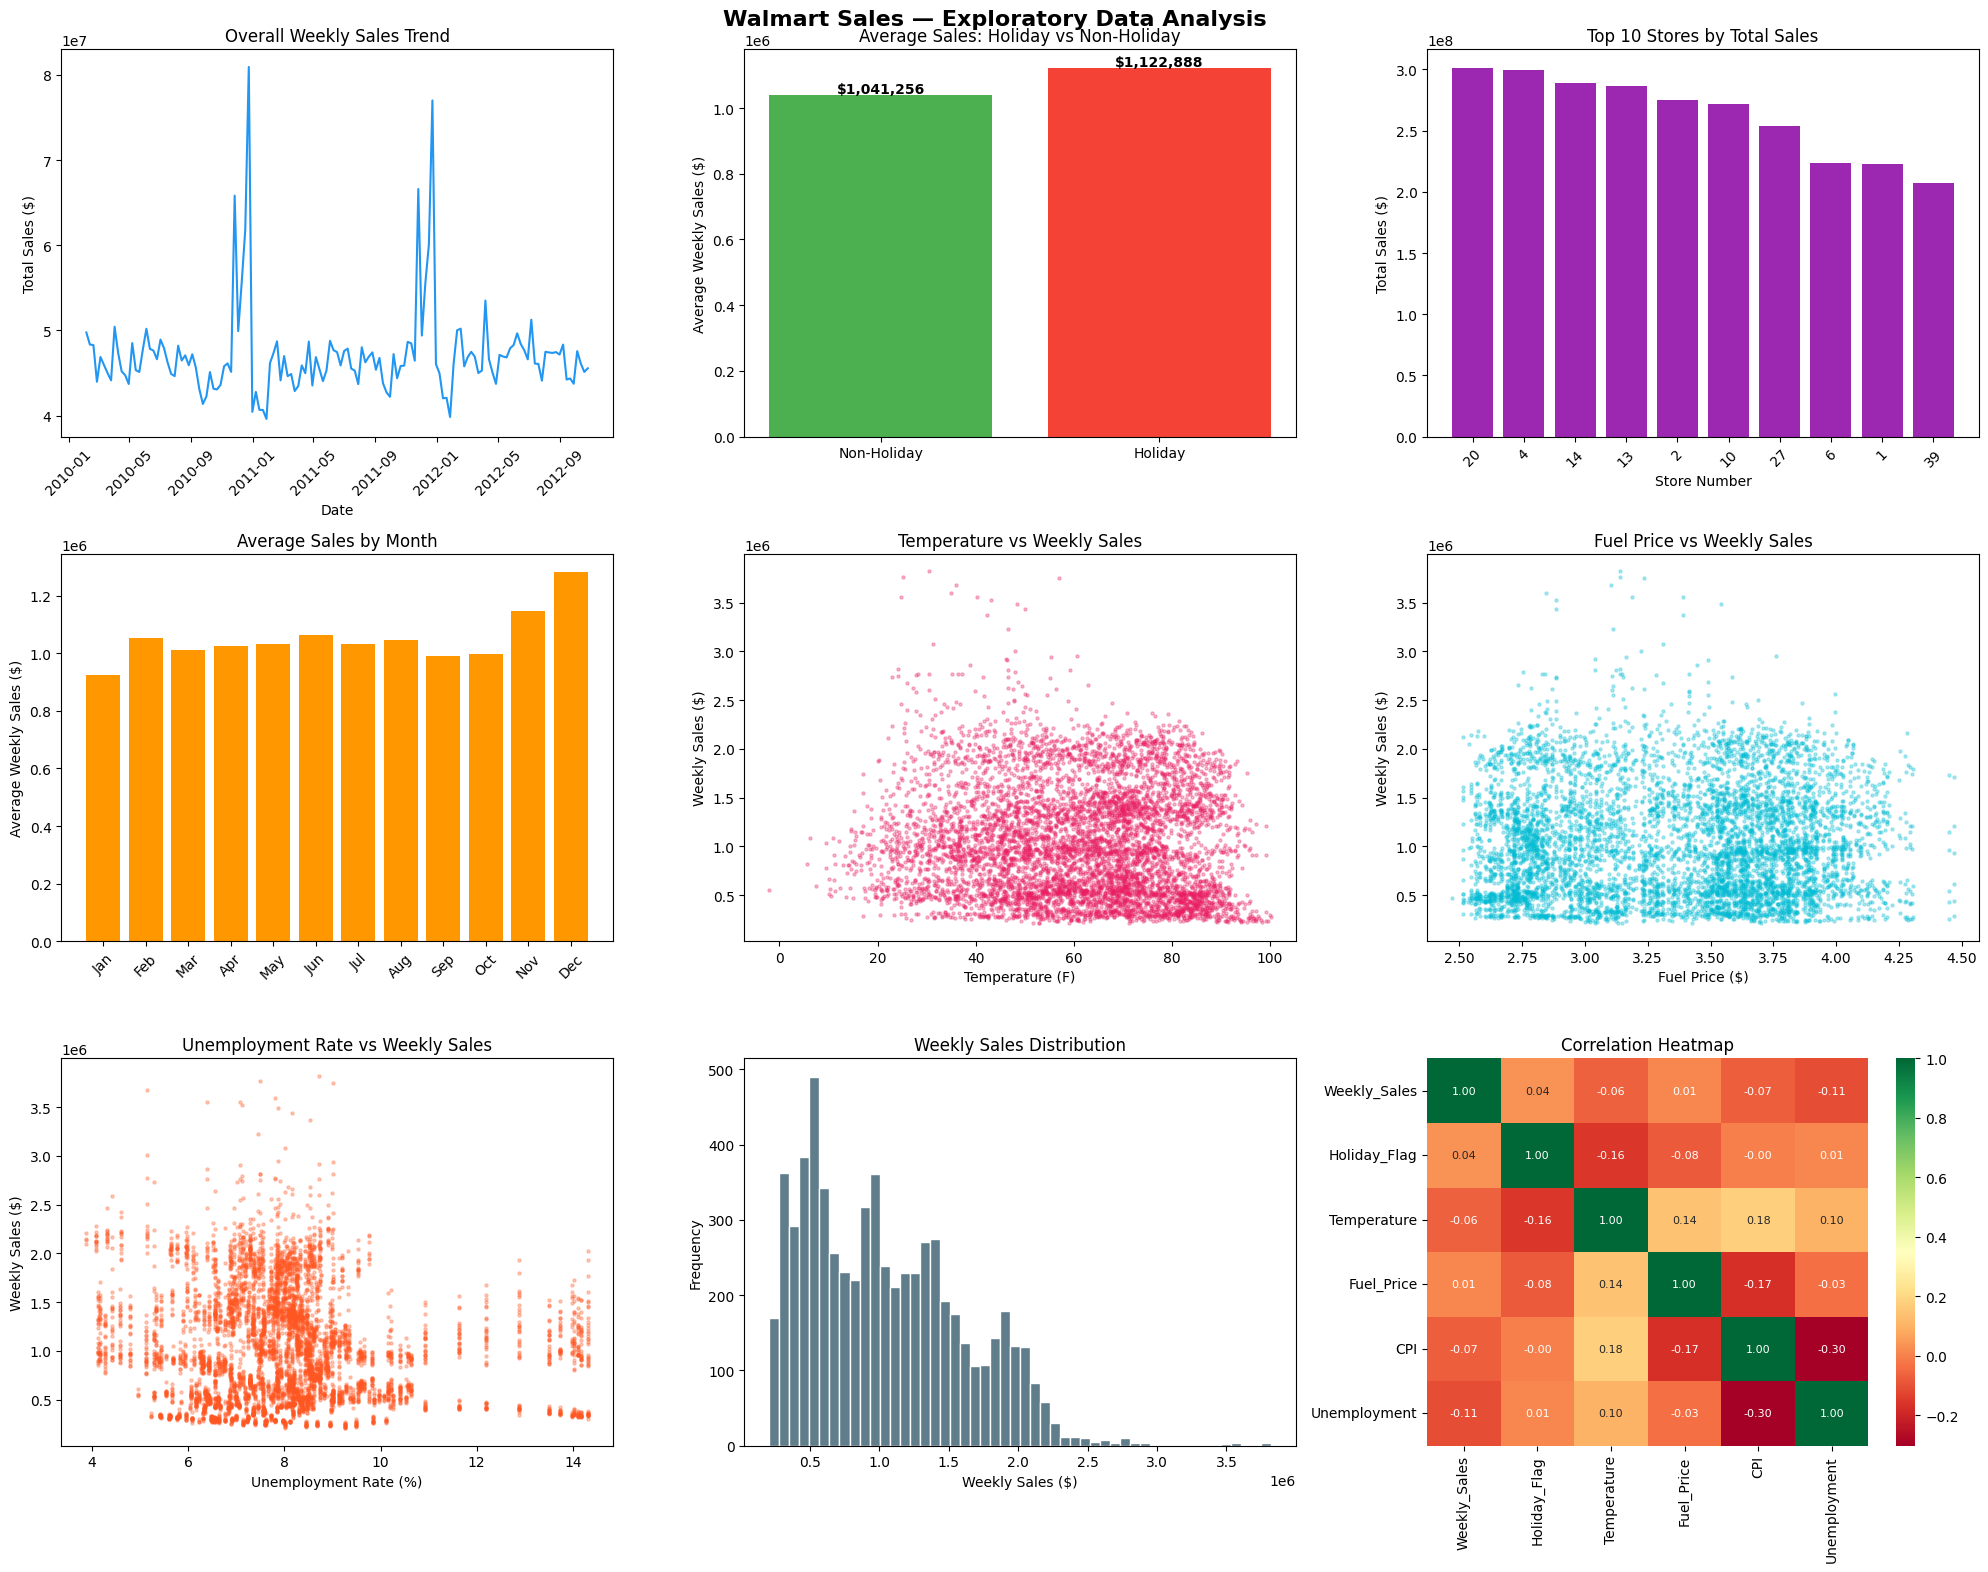

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('Walmart Sales — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Overall Sales Trend
total_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
axes[0,0].plot(total_sales['Date'], total_sales['Weekly_Sales'], color='#2196F3', linewidth=1.5)
axes[0,0].set_title('Overall Weekly Sales Trend')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Total Sales ($)')
axes[0,0].tick_params(axis='x', rotation=45)

# Holiday vs Non-Holiday
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
axes[0,1].bar(['Non-Holiday', 'Holiday'], holiday_sales.values, color=['#4CAF50', '#F44336'])
axes[0,1].set_title('Average Sales: Holiday vs Non-Holiday')
axes[0,1].set_ylabel('Average Weekly Sales ($)')
for i, v in enumerate(holiday_sales.values):
    axes[0,1].text(i, v + 5000, f'${v:,.0f}', ha='center', fontweight='bold')

# Top 10 Stores
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)
axes[0,2].bar(store_sales.index.astype(str), store_sales.values, color='#9C27B0')
axes[0,2].set_title('Top 10 Stores by Total Sales')
axes[0,2].set_xlabel('Store Number')
axes[0,2].set_ylabel('Total Sales ($)')
axes[0,2].tick_params(axis='x', rotation=45)

# Monthly Seasonality
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,0].bar(month_names, monthly_sales.values, color='#FF9800')
axes[1,0].set_title('Average Sales by Month')
axes[1,0].set_ylabel('Average Weekly Sales ($)')
axes[1,0].tick_params(axis='x', rotation=45)

# Temperature vs Sales
axes[1,1].scatter(df['Temperature'], df['Weekly_Sales'], alpha=0.3, color='#E91E63', s=5)
axes[1,1].set_title('Temperature vs Weekly Sales')
axes[1,1].set_xlabel('Temperature (F)')
axes[1,1].set_ylabel('Weekly Sales ($)')

# Fuel Price vs Sales
axes[1,2].scatter(df['Fuel_Price'], df['Weekly_Sales'], alpha=0.3, color='#00BCD4', s=5)
axes[1,2].set_title('Fuel Price vs Weekly Sales')
axes[1,2].set_xlabel('Fuel Price ($)')
axes[1,2].set_ylabel('Weekly Sales ($)')

# Unemployment vs Sales
axes[2,0].scatter(df['Unemployment'], df['Weekly_Sales'], alpha=0.3, color='#FF5722', s=5)
axes[2,0].set_title('Unemployment Rate vs Weekly Sales')
axes[2,0].set_xlabel('Unemployment Rate (%)')
axes[2,0].set_ylabel('Weekly Sales ($)')

# Sales Distribution
axes[2,1].hist(df['Weekly_Sales'], bins=50, color='#607D8B', edgecolor='white')
axes[2,1].set_title('Weekly Sales Distribution')
axes[2,1].set_xlabel('Weekly Sales ($)')
axes[2,1].set_ylabel('Frequency')

# Correlation Heatmap
num_cols = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[2,2], annot_kws={'size': 8})
axes[2,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_walmart.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
holiday_df = df[df['Holiday_Flag'] == 1]
non_holiday_df = df[df['Holiday_Flag'] == 0]

avg_holiday = holiday_df['Weekly_Sales'].mean()
avg_non_holiday = non_holiday_df['Weekly_Sales'].mean()
holiday_boost = ((avg_holiday - avg_non_holiday) / avg_non_holiday) * 100

print(f"Average Holiday Sales: ${avg_holiday:,.2f}")
print(f"Average Non-Holiday Sales: ${avg_non_holiday:,.2f}")
print(f"Holiday Sales Boost: {holiday_boost:.1f}%")

holiday_weeks = df[df['Holiday_Flag'] == 1].groupby('Date')['Weekly_Sales'].sum().sort_values(ascending=False)
print(f"\nTop 5 Holiday Weeks by Total Sales:")
print(holiday_weeks.head())

Average Holiday Sales: $1,128,303.39
Average Non-Holiday Sales: $1,041,012.50
Holiday Sales Boost: 8.4%

Top 5 Holiday Weeks by Total Sales:
Date
2011-11-25    66593605.26
2010-11-26    65821003.24
2012-02-10    50009407.92
2012-09-07    48330059.31
2011-02-11    47336192.79
Name: Weekly_Sales, dtype: float64


Store Segmentation:
Segment
Low Performing       15
Medium Performing    15
High Performing      15
Name: count, dtype: int64

Top 5 High Performing Stores:
    Store   Total_Sales  Avg_Weekly_Sales   Max_Sales   Min_Sales  \
19     20  2.928275e+08      2.106673e+06  3766687.43  1761016.51   
3       4  2.912449e+08      2.095287e+06  3676388.98  1762539.30   
13     14  2.803721e+08      2.017065e+06  3818686.45  1479514.66   
12     13  2.787314e+08      2.005262e+06  3595903.20  1633663.12   
1       2  2.671181e+08      1.921713e+06  3436007.68  1650394.44   

            Segment  
19  High Performing  
3   High Performing  
13  High Performing  
12  High Performing  
1   High Performing  


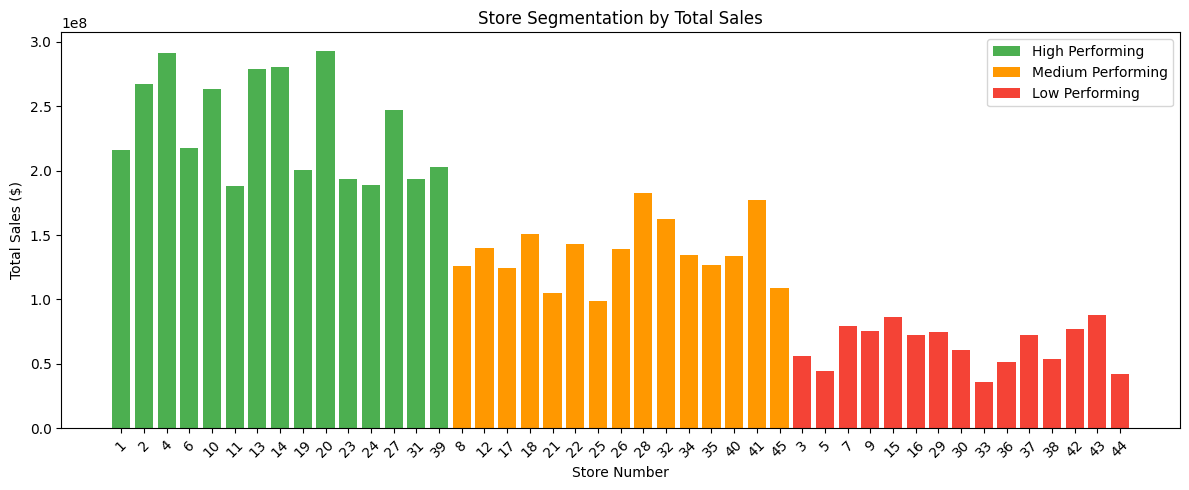

In [46]:
store_stats = df.groupby('Store').agg(
    Total_Sales=('Weekly_Sales', 'sum'),
    Avg_Weekly_Sales=('Weekly_Sales', 'mean'),
    Max_Sales=('Weekly_Sales', 'max'),
    Min_Sales=('Weekly_Sales', 'min')
).reset_index()

store_stats['Segment'] = pd.qcut(
    store_stats['Total_Sales'],
    q=3,
    labels=['Low Performing', 'Medium Performing', 'High Performing']
)

print("Store Segmentation:")
print(store_stats['Segment'].value_counts())
print("\nTop 5 High Performing Stores:")
print(store_stats[store_stats['Segment'] == 'High Performing'].sort_values('Total_Sales', ascending=False).head())

plt.figure(figsize=(12, 5))
colors = {'High Performing': '#4CAF50', 'Medium Performing': '#FF9800', 'Low Performing': '#F44336'}
for segment, color in colors.items():
    seg_stores = store_stats[store_stats['Segment'] == segment]
    plt.bar(seg_stores['Store'].astype(str), seg_stores['Total_Sales'], color=color, label=segment)
plt.title('Store Segmentation by Total Sales')
plt.xlabel('Store Number')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('store_segmentation.png', dpi=150)
plt.show()

In [47]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
}

comparison_results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    mae_val = mean_absolute_error(y_test, pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, pred))
    mape_val = np.mean(np.abs((y_test - pred) / y_test)) * 100
    comparison_results.append({'Model': name, 'MAE': mae_val, 'RMSE': rmse_val, 'MAPE': mape_val})

comparison_df = pd.DataFrame(comparison_results).sort_values('MAPE')
print(comparison_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001766 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2651
[LightGBM] [Info] Number of data points in the train set: 5004, number of used features: 15
[LightGBM] [Info] Start training from score 1117167.222787
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [49]:
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

df['Lag_1'] = df.groupby('Store')['Weekly_Sales'].shift(1)
df['Lag_2'] = df.groupby('Store')['Weekly_Sales'].shift(2)
df['Lag_4'] = df.groupby('Store')['Weekly_Sales'].shift(4)
df['Rolling_Mean_4'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x.shift(1).rolling(4).mean())
df['Rolling_Std_4'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x.shift(1).rolling(4).std())
df['Sales_Growth'] = df.groupby('Store')['Weekly_Sales'].pct_change()

df = df.dropna().reset_index(drop=True)
print(f"After feature engineering: {df.shape}")
print(df[['Store', 'Date', 'Weekly_Sales', 'Lag_1', 'Rolling_Mean_4']].head())

After feature engineering: (6075, 17)
   Store       Date  Weekly_Sales       Lag_1  Rolling_Mean_4
0      1 2010-04-02    1594968.28  1404429.92    1.467823e+06
1      1 2010-04-09    1545418.53  1594968.28    1.477864e+06
2      1 2010-04-16    1466058.28  1545418.53    1.504333e+06
3      1 2010-04-23    1391256.12  1466058.28    1.502719e+06
4      1 2010-04-30    1425100.71  1391256.12    1.499425e+06


In [50]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import pickle

feature_cols = ['Store', 'Month', 'Year', 'Week', 'Holiday_Flag',
                'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
                'Lag_1', 'Lag_2', 'Lag_4', 'Rolling_Mean_4',
                'Rolling_Std_4', 'Sales_Growth']

X = df[feature_cols]
y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: $8,682.27
RMSE: $19,259.32
MAPE: 1.22%


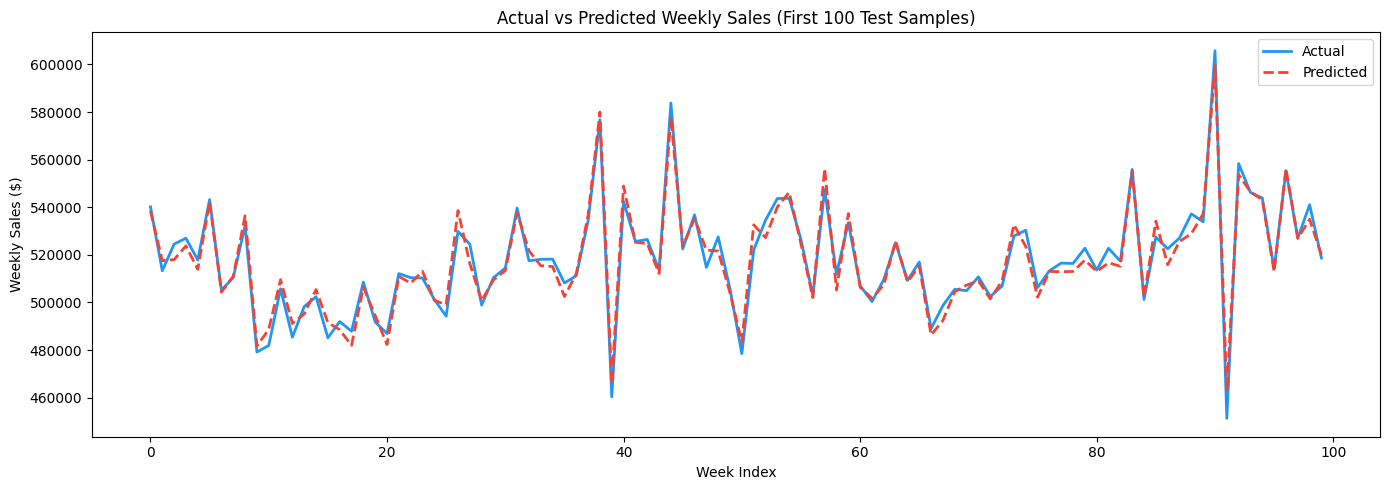

In [51]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:100], label='Actual', color='#2196F3', linewidth=2)
plt.plot(y_pred[:100], label='Predicted', color='#F44336', linewidth=2, linestyle='--')
plt.title('Actual vs Predicted Weekly Sales (First 100 Test Samples)')
plt.xlabel('Week Index')
plt.ylabel('Weekly Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

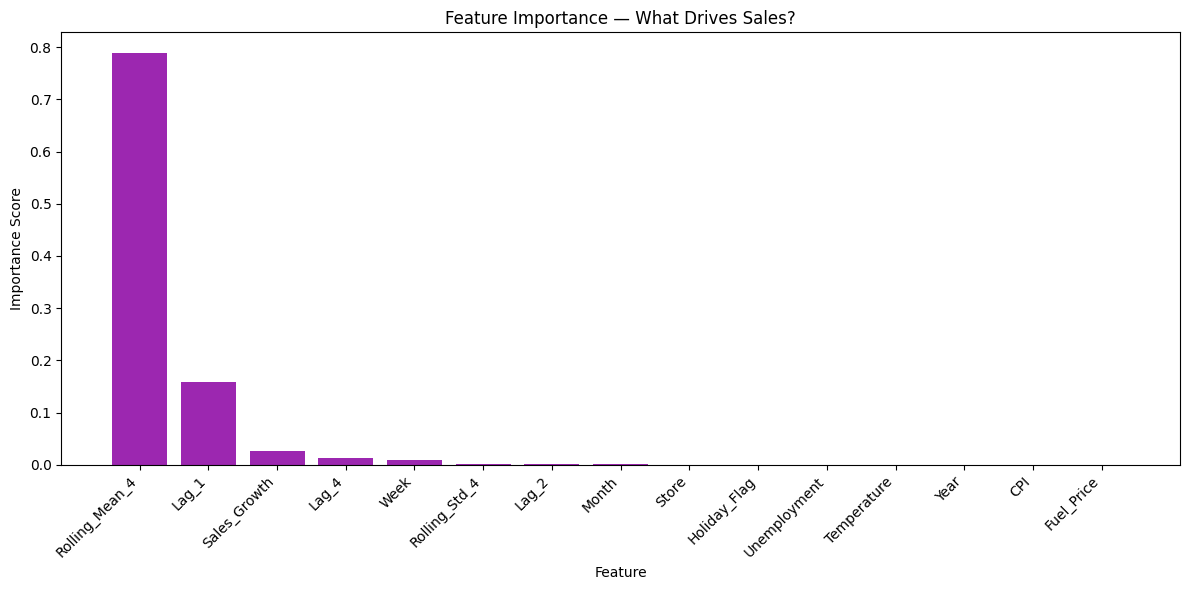

           Feature  Importance
12  Rolling_Mean_4    0.788904
9            Lag_1    0.159321
14    Sales_Growth    0.026738
11           Lag_4    0.012249
3             Week    0.008497
13   Rolling_Std_4    0.000938
10           Lag_2    0.000863
1            Month    0.000843
0            Store    0.000468
4     Holiday_Flag    0.000295
8     Unemployment    0.000265
5      Temperature    0.000250
2             Year    0.000179
7              CPI    0.000109
6       Fuel_Price    0.000083


In [52]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'], color='#9C27B0')
plt.title('Feature Importance — What Drives Sales?')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print(importance_df)

In [53]:
baseline_pred = X_test['Lag_1'].values  # naive: predict this week = last week's sales

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mape = np.mean(np.abs((y_test - baseline_pred) / y_test)) * 100

print(f"Baseline (Naive Lag-1) — MAE: ${baseline_mae:,.2f} | RMSE: ${baseline_rmse:,.2f} | MAPE: {baseline_mape:.2f}%")
print(f"XGBoost               — MAE: ${mae:,.2f} | RMSE: ${rmse:,.2f} | MAPE: {mape:.2f}%")
print(f"Improvement over baseline: {baseline_mape - mape:.2f} percentage points in MAPE")

Baseline (Naive Lag-1) — MAE: $58,999.14 | RMSE: $126,437.90 | MAPE: 7.06%
XGBoost               — MAE: $8,682.27 | RMSE: $19,259.32 | MAPE: 1.22%
Improvement over baseline: 5.84 percentage points in MAPE


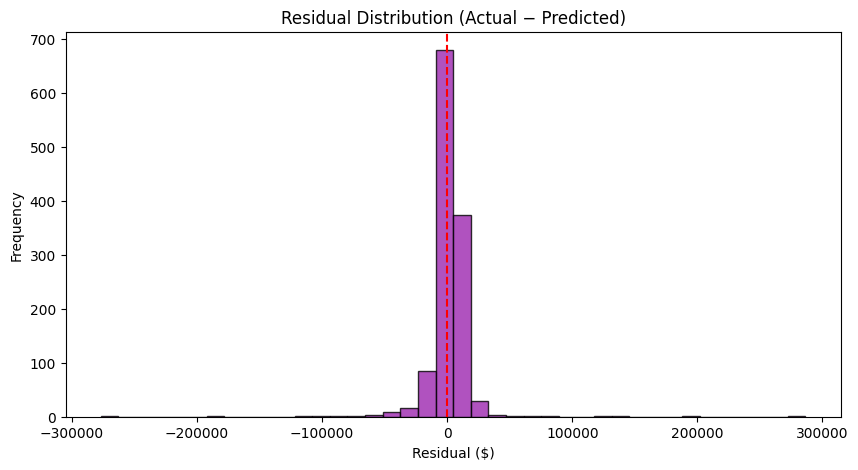

Mean residual: $1,080.63 (close to 0 = no systematic bias)


In [54]:
residuals = y_test.values - y_pred

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=40, color='#9C27B0', edgecolor='black', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Distribution (Actual − Predicted)')
plt.xlabel('Residual ($)')
plt.ylabel('Frequency')
plt.savefig('residuals.png', dpi=150)
plt.show()

print(f"Mean residual: ${residuals.mean():,.2f} (close to 0 = no systematic bias)")